In [1]:
# Install (run once)
import sys
!{sys.executable} -m pip install river xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\sbhol\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
#Section 1 : Import and Setup
# Core libraries
import pandas as pd
import numpy as np
import glob
import time

# ML models
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

# Preprocessing
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    recall_score, precision_score, f1_score, roc_curve
)

# Drift detection
from river.drift import ADWIN

print("All imports successful.")

All imports successful.


In [3]:
#Section 2 : Data Loading
# Path to dataset
path = r"C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\*.csv"
files = sorted(glob.glob(path))

train_files = files[:7]
test_files = files[7:]

# Load limited rows per file (IMPORTANT for laptop safety)
def load_data_sampled(file_list, rows_per_file=8000):
    df_list = []
    
    for file in file_list:
        print(f"Loading: {file}")
        
        chunks = pd.read_csv(file, chunksize=50000, low_memory=False)
        
        for chunk in chunks:
            chunk = chunk[chunk['Label'] != 'Label']
            df_list.append(chunk.head(rows_per_file))
            break   # Only first chunk → prevents overload
            
    return pd.concat(df_list, ignore_index=True)

train_df = load_data_sampled(train_files)
test_df = load_data_sampled(test_files)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-14-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-15-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-16-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-20-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-21-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-22-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-23-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\02-28-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\03-01-2018.csv
Loading: C:\Shravani Data\Study\ENGINEERING\TE\SEM 6\Major Project\archive\03-02-2018.csv
Train shape: (56000, 84)
Test shape: (24000, 80)


In [4]:
#section 3 : Preprocessing
def preprocess(df):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp'])
    df = df.sort_values(by='Timestamp')
    df = df.drop_duplicates()

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    df.drop(columns=['Flow ID','Src IP','Dst IP','Src Port'],
            errors='ignore', inplace=True)

    df['Label'] = df['Label'].apply(
        lambda x: 0 if str(x).strip().lower()=='benign' else 1
    )

    X = df.drop(columns=['Label','Timestamp'], errors='ignore')
    y = df['Label']

    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.fillna(0)

    return X, y

X_train_raw, y_train = preprocess(train_df)
X_test_raw, y_test = preprocess(test_df)

C:\Users\sbhol\AppData\Local\Temp\ipykernel_20948\1824486035.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
C:\Users\sbhol\AppData\Local\Temp\ipykernel_20948\1824486035.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


In [5]:
#section 4 : feature engineering
def feature_engineering(X):
    X = X.copy()

    def safe(col):
        return col if col in X.columns else None

    if safe('TotLen Fwd Pkts') and safe('Total Fwd Packets'):
        X['bytes_per_pkt'] = X['TotLen Fwd Pkts'] / (X['Total Fwd Packets'] + 1)

    if safe('Fwd Pkts/s') and safe('Flow Pkts/s'):
        X['pkt_rate_ratio'] = X['Fwd Pkts/s'] / (X['Flow Pkts/s'] + 1)

    if safe('Flow IAT Std') and safe('Flow IAT Mean'):
        X['iat_variation'] = X['Flow IAT Std'] / (X['Flow IAT Mean'] + 1)

    return X

X_train_raw = feature_engineering(X_train_raw)
X_test_raw = feature_engineering(X_test_raw)


In [6]:
#section 5 - Feature selection
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)

mi = mutual_info_classif(X_train_raw, y_train)
mi_series = pd.Series(mi, index=X_train_raw.columns).sort_values(ascending=False)

TOP_N = 25
top_features = mi_series.head(TOP_N).index.tolist()

X_train = X_train_raw[top_features]
X_test = X_test_raw[top_features]

In [7]:
#Section 6 - Scaling
# ========================
# SECTION 6: SCALING (FIXED ✅)
# ========================

# Step 1: Replace inf values
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 2: Fill NaN
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

# Step 3: Clip extreme values (VERY IMPORTANT 🔥)
X_train = np.clip(X_train, -1e9, 1e9)
X_test = np.clip(X_test, -1e9, 1e9)

# Step 4: Convert to float
X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)

# Step 5: Scaling
scaler = RobustScaler()

X_benign = X_train[y_train == 0]

X_benign_scaled = scaler.fit_transform(X_benign)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


C:\Users\sbhol\AppData\Local\Temp\ipykernel_20948\3273706617.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\sbhol\AppData\Local\Temp\ipykernel_20948\3273706617.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\sbhol\AppData\Local\Temp\ipykernel_20948\3273706617.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ve

In [8]:
#Section 7 - Model Training Hybrid (XGB + Isolation Forest)
# ========================
# SECTION 7: MODEL TRAINING (TUNED 🔥)
# ========================

# -------- Isolation Forest --------
iso = IsolationForest(
    n_estimators=500,        # more trees → better detection
    max_samples=512,         # subset size
    contamination=0.12,      # slightly tuned (not exact test ratio)
    max_features=0.8,        # randomness helps generalization
    random_state=42,
    n_jobs=-1
)

iso.fit(X_benign_scaled)

# -------- XGBoost --------
xgb = XGBClassifier(
    n_estimators=300,        # more trees → better learning
    max_depth=6,             # control overfitting
    learning_rate=0.08,      # smaller = better generalization
    subsample=0.8,           # randomness
    colsample_bytree=0.8,    # feature sampling
    gamma=0.1,               # regularization
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)

print("Tuned models trained successfully.")

Tuned models trained successfully.


In [9]:
#section 8 - Hybrid Scoring
if_scores = iso.score_samples(X_test_scaled)

# FIXED normalization
if_norm = (if_scores.max() - if_scores) / (if_scores.max() - if_scores.min())

xgb_probs = xgb.predict_proba(X_test)[:,1]

alpha = 0.3  # IMPORTANT CHANGE
hybrid_score = alpha*if_norm + (1-alpha)*xgb_probs

In [10]:
#Section  9 - Threshold ROC
best_thresh = 0
best_f1 = 0

for t in np.linspace(0,1,100):
    yp = (hybrid_score >= t).astype(int)
    f1 = f1_score(y_test, yp, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

y_pred = (hybrid_score >= best_thresh).astype(int)

Best Threshold: 0.22222222222222224


In [11]:
#Section 10 - ADWIN
print("\n" + "="*60)
print(" REAL-TIME IDS SIMULATION — HYBRID MODEL + ADWIN")
print("="*60)

adwin = ADWIN(delta=0.002)

drift_points = []
drift_count = 0

for i in range(min(200, len(X_test))):

    score = hybrid_score[i]
    pred = 1 if score >= best_thresh else 0
    actual = int(y_test.iloc[i])

    # CORRECT drift input
    error = int(pred != actual)
    adwin.update(error)

    drift_detected = adwin.drift_detected

    if drift_detected:
        drift_count += 1
        drift_points.append(i)

    actual_label = "ATTACK" if actual else "BENIGN"
    pred_label = "ATTACK" if pred else "BENIGN"

    correct = "✓" if pred == actual else "✗"
    drift_flag = "⚠ DRIFT" if drift_detected else ""

    print(f"Flow {i:4d} | Score: {score:.4f} | Pred: {pred_label:6s} | "
          f"Actual: {actual_label:6s} | {correct} {drift_flag}")

    time.sleep(0.005)

print("\nTotal drift events:", drift_count)
print("Drift points:", drift_points)


 REAL-TIME IDS SIMULATION — HYBRID MODEL + ADWIN
Flow    0 | Score: 0.0154 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    1 | Score: 0.0089 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    2 | Score: 0.1062 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    3 | Score: 0.0091 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    4 | Score: 0.1166 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    5 | Score: 0.0156 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    6 | Score: 0.0134 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    7 | Score: 0.0081 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    8 | Score: 0.1073 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow    9 | Score: 0.2238 | Pred: ATTACK | Actual: BENIGN | ✗ 
Flow   10 | Score: 0.1174 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow   11 | Score: 0.0153 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow   12 | Score: 0.0146 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow   13 | Score: 0.1103 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow   14 | Score: 0.1820 | Pred: BENIGN | Actual: BENIGN | ✓ 
Flow 

In [12]:
#Section 11 - Final Evaluation
print("\n=== HYBRID MODEL RESULTS ===\n")

print(classification_report(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


=== HYBRID MODEL RESULTS ===

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     17448
           1       0.92      0.97      0.94      6538

    accuracy                           0.97     23986
   macro avg       0.95      0.97      0.96     23986
weighted avg       0.97      0.97      0.97     23986

Recall: 0.9658917100030591
Precision: 0.9209566865976374
F1: 0.9428891377379619


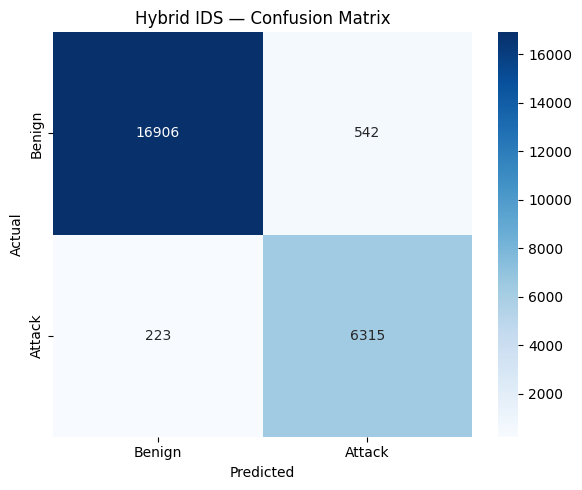

In [13]:
#Section 12 : Visualization
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign","Attack"],
            yticklabels=["Benign","Attack"])

plt.title("Hybrid IDS — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

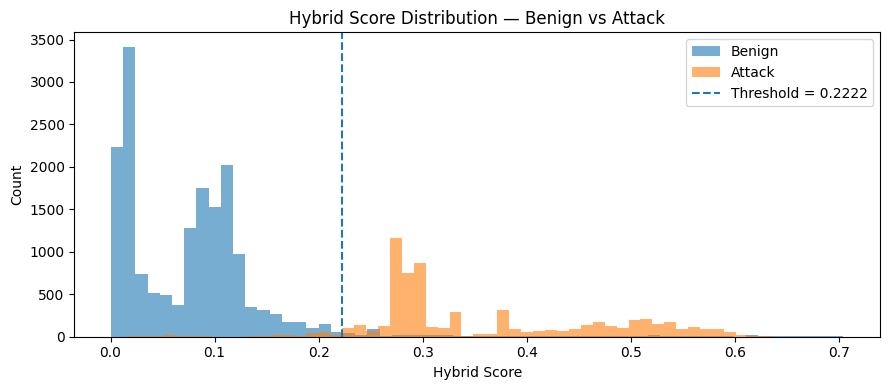

In [14]:
plt.figure(figsize=(9,4))

plt.hist(hybrid_score[y_test==0], bins=60, alpha=0.6, label="Benign")
plt.hist(hybrid_score[y_test==1], bins=60, alpha=0.6, label="Attack")

plt.axvline(x=best_thresh, linestyle='--',
            label=f"Threshold = {best_thresh:.4f}")

plt.title("Hybrid Score Distribution — Benign vs Attack")
plt.xlabel("Hybrid Score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

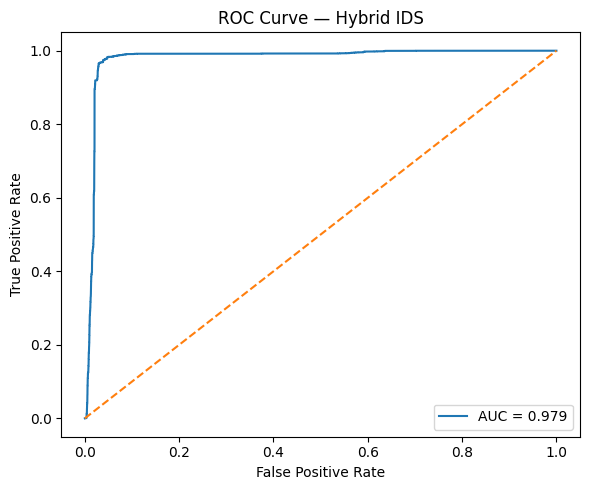

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, hybrid_score)
auc = roc_auc_score(y_test, hybrid_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Hybrid IDS")
plt.legend()
plt.tight_layout()
plt.show()

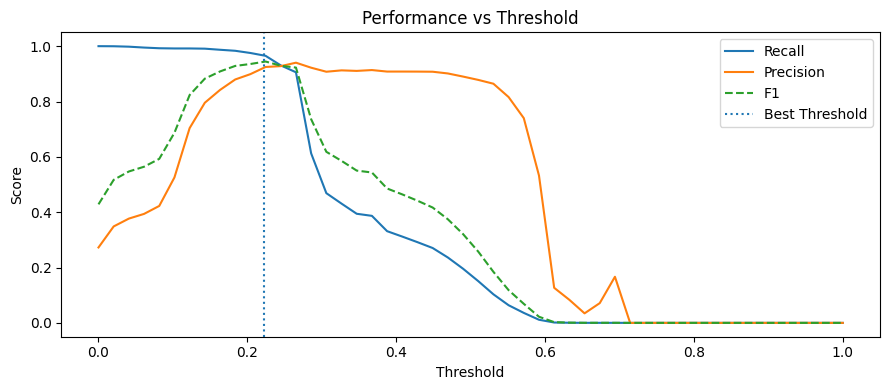

In [16]:
precisions, recalls, f1s = [], [], []
ths = np.linspace(0,1,50)

for t in ths:
    yp = (hybrid_score >= t).astype(int)
    precisions.append(precision_score(y_test, yp, zero_division=0))
    recalls.append(recall_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))

plt.figure(figsize=(9,4))
plt.plot(ths, recalls, label="Recall")
plt.plot(ths, precisions, label="Precision")
plt.plot(ths, f1s, linestyle='--', label="F1")

plt.axvline(x=best_thresh, linestyle=':', label="Best Threshold")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Performance vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

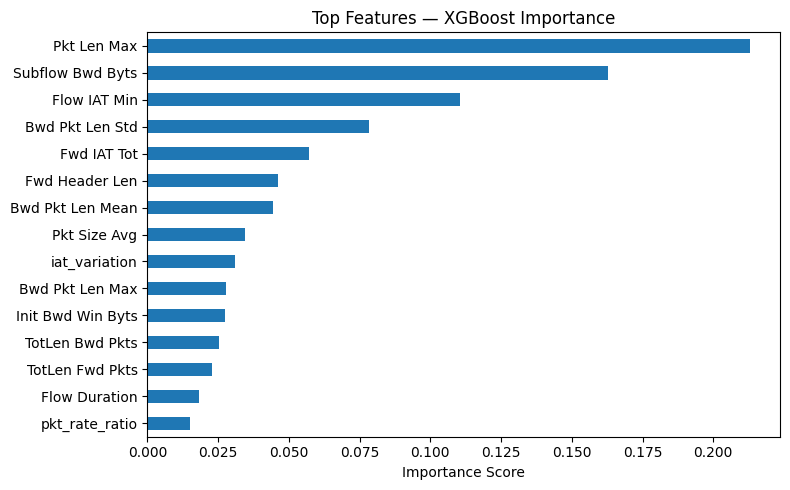

In [17]:
importances = xgb.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
feat_imp.sort_values().plot(kind='barh')

plt.title("Top Features — XGBoost Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [18]:
if drift_points:
    plt.figure(figsize=(10,3))

    plt.plot(predictions, label="Prediction", alpha=0.7)
    plt.plot(y_test.iloc[:len(predictions)].values,
             label="Actual", alpha=0.4)

    for dp in drift_points:
        plt.axvline(x=dp, linestyle='--')

    plt.title("ADWIN Drift Detection Timeline")
    plt.xlabel("Flow Index")
    plt.ylabel("Label")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No drift detected (data distribution stable)")

No drift detected (data distribution stable)


In [19]:
#Section 13 - SHAP
!pip install shap

import shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\sbhol\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb)

# Use small sample (IMPORTANT for laptop 💻)
X_sample = X_test.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

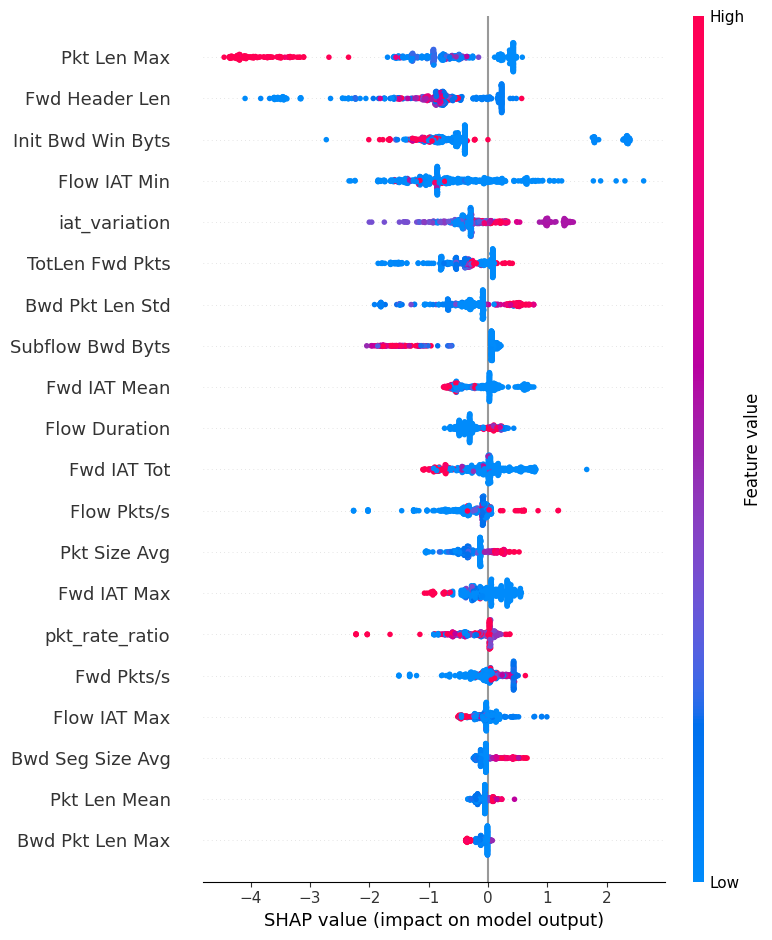

In [21]:
shap.summary_plot(shap_values, X_sample)

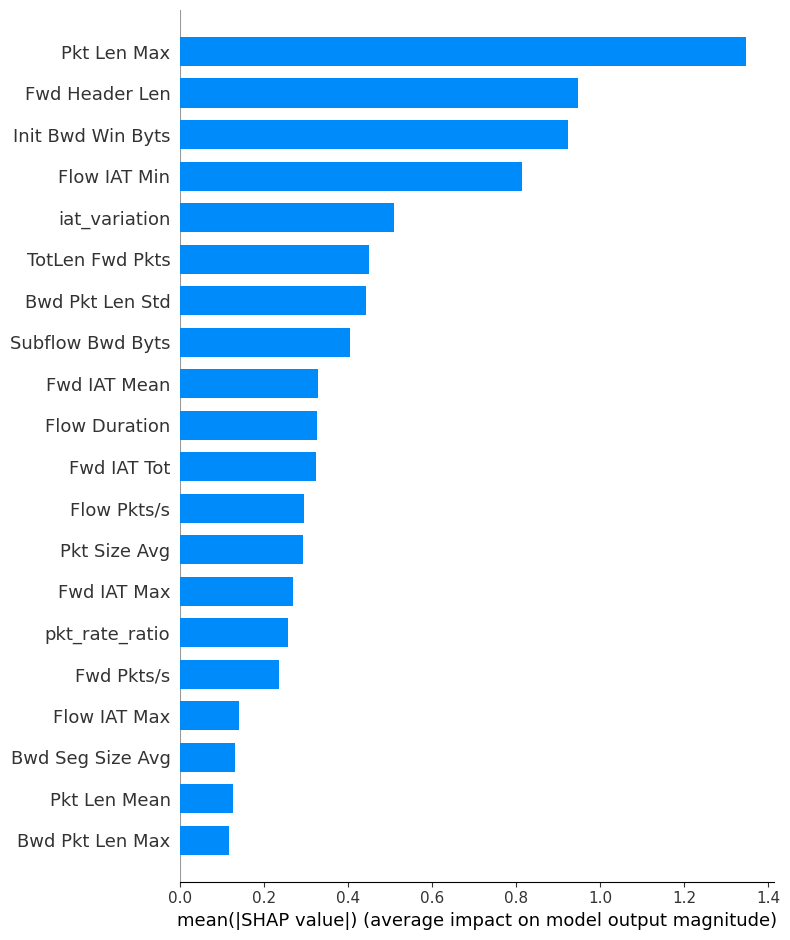

In [22]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

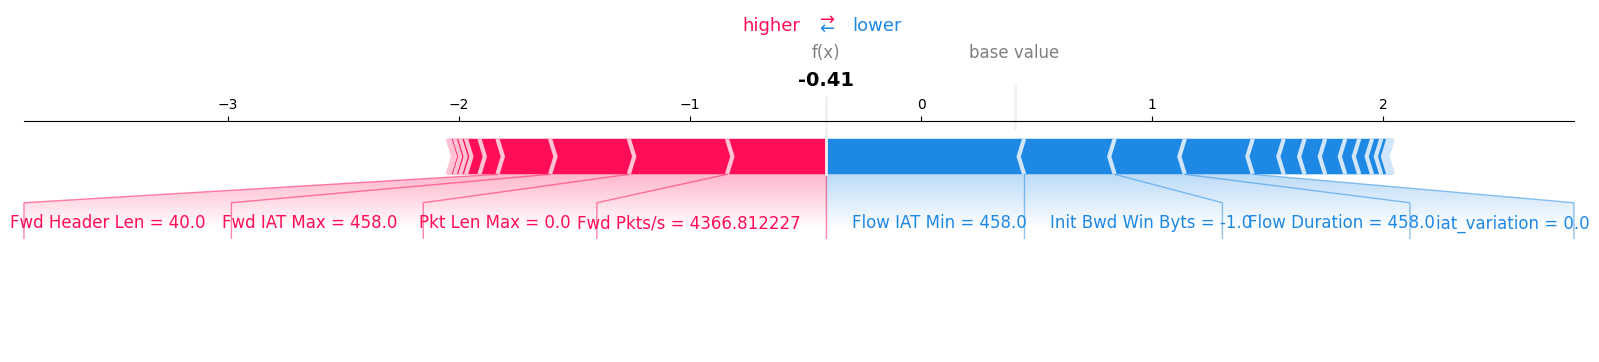

In [23]:
# Explain single flow
idx = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_sample.iloc[idx],
    matplotlib=True
)

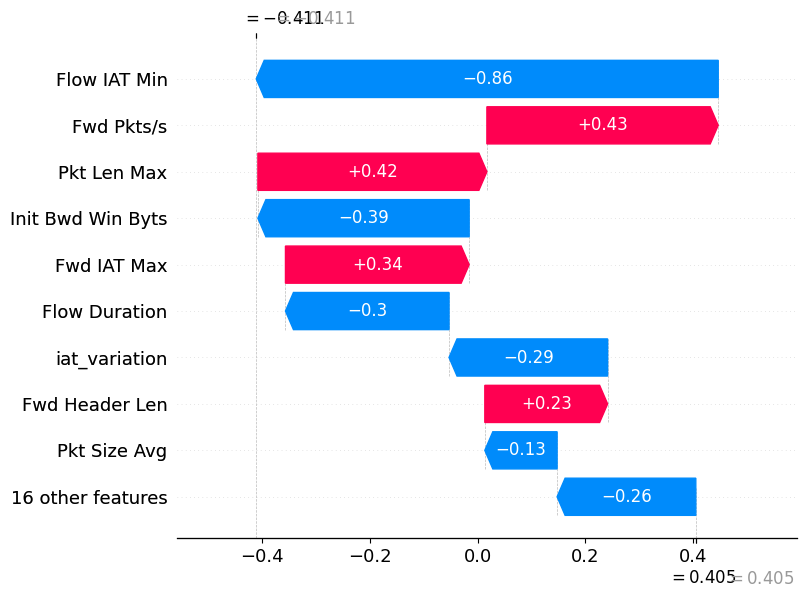

In [24]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=X_sample.columns
)

In [25]:
import os
import joblib

# Path to the models folder (one level above notebooks)
MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

# Save trained models
joblib.dump(xgb, os.path.join(MODEL_DIR, "xgb_model.pkl"))
joblib.dump(iso, os.path.join(MODEL_DIR, "isolation_forest.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))

# Save important deployment objects
joblib.dump(top_features, os.path.join(MODEL_DIR, "top_features.pkl"))
joblib.dump(best_thresh, os.path.join(MODEL_DIR, "threshold.pkl"))

print("✅ All deployment files saved successfully!")

✅ All deployment files saved successfully!
